# **Modelo base y protocolo de evaluación — MUNICIPIO C**

En este notebook fijamos el **protocolo de evaluación** del proyecto y construimos una
**línea base** contra la cual se comparará todo modelo posterior. Trabajamos sobre una
única serie diaria —la del municipio con más siniestros registrados— para poner el
procedimiento en marcha sobre un caso simple antes de llevarlo al panel de los ocho
municipios.

Puntos que cubre, en el orden en que los pide la guía del Entregable 2:

1. **Un protocolo de evaluación válido:** particiones cronológicas, validación temporal
   interna y métricas apropiadas para un objetivo de conteo, sin fugas de información.
2. **Un conjunto de prueba reservado** que no se usa para ajustar procedimientos ni para
   seleccionar modelos: se toca una sola vez, al final.
3. **Una línea base adecuada** y una **interpretación de los resultados preliminares**.

### Qué NO hace este notebook

- No busca hiperparámetros ni compara familias de modelos: eso es el Entregable 3.
- No trabaja el panel completo (8 municipios). La serie de MUNICIPIO C **no es
  representativa** del proyecto —el diagnóstico mostró que los ocho municipios se
  parecen mucho entre sí (razón máx/mín 1,71×)— y sus métricas no son las del proyecto.
  La evaluación seria, desagregada por municipio, queda para el notebook siguiente
  (ver `documentacion/resumen_diagnostico_datos.md`, §5.4).
- No redacta Introducción ni Marco teórico.

### De dónde sale cada decisión

Las decisiones de métrica, forma de la línea base y tratamiento de la fuga vienen del
diagnóstico de datos, que las midió en lugar de postularlas
(`documentacion/resumen_diagnostico_datos.md`, §5.1 a §5.3). Este notebook las **aplica**
y deja los artefactos (`experiments/base/`) para citar desde el informe.

## Importación de librerías

Usamos únicamente `pandas`, `numpy`, `matplotlib` y `scikit-learn`, ya presentes en
`requirements.txt`. No incorporamos ninguna dependencia nueva: el backtesting de ventana
deslizante se implementa a mano en la sección 7, de modo que el procedimiento quede a la
vista y sea auditable.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Rutas y utilidades
from pathlib import Path
import platform

# Visualización
import matplotlib
import matplotlib.pyplot as plt

# Métricas y modelo base aprendido
import sklearn
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# Semilla global: hoy no hay nada aleatorio, pero lo dejamos fijado por si se agrega.
SEMILLA = 20260910
np.random.seed(SEMILLA)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)
print("python      ", platform.python_version())

pandas       3.0.5
numpy        2.5.2
matplotlib   3.11.1
scikit-learn 1.9.0
python       3.14.7


## Configuración de rutas

El notebook resuelve la raíz del repositorio sola, tanto si se ejecuta desde
`notebooks/` como desde la raíz. Los artefactos (tablas CSV y figuras PNG) se escriben en
`experiments/base/`, siguiendo la convención del diagnóstico y del ETL.

In [2]:
# Resolución robusta de la raíz del repositorio.
_cwd = Path.cwd()
if (_cwd / "data" / "processed" / "panel_zona_top.csv").exists():
    RAIZ = _cwd
elif (_cwd.parent / "data" / "processed" / "panel_zona_top.csv").exists():
    RAIZ = _cwd.parent
else:
    raise FileNotFoundError("No se encuentra data/processed/panel_zona_top.csv")

RUTA_DATOS = RAIZ / "data" / "processed" / "panel_zona_top.csv"
DIR_TABLAS = RAIZ / "experiments" / "base" / "tablas"
DIR_FIGURAS = RAIZ / "experiments" / "base" / "figuras"
DIR_TABLAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raíz del repositorio:", RAIZ)
print("Dataset             :", RUTA_DATOS.relative_to(RAIZ))
print("Tablas              :", DIR_TABLAS.relative_to(RAIZ))
print("Figuras             :", DIR_FIGURAS.relative_to(RAIZ))


def guardar_tabla(df, nombre):
    "Escribe un CSV en experiments/base/tablas y devuelve el DataFrame sin tocar."
    ruta = DIR_TABLAS / nombre
    df.to_csv(ruta, index=False)
    print("  guardado:", ruta.relative_to(RAIZ), f"({len(df)} filas)")
    return df


def guardar_figura(fig, nombre):
    "Escribe un PNG en experiments/base/figuras."
    ruta = DIR_FIGURAS / nombre
    fig.savefig(ruta, bbox_inches="tight")
    print("  guardado:", ruta.relative_to(RAIZ))

Raíz del repositorio: C:\Users\Samuca\OneDrive\Desktop\Proyectos\proyecto-machine-learning
Dataset             : data\processed\panel_zona_top.csv
Tablas              : experiments\base\tablas
Figuras             : experiments\base\figuras


## 1. Carga y estructura de la serie

El archivo `panel_zona_top.csv` es la serie diaria de **MUNICIPIO C**, el municipio con
más siniestros registrados en el período (`documentacion/resumen_preparacion_montevideo.md`,
§7.5). Cada fila es un día; la columna objetivo es `n_siniestros`.

La fecha viene en formato ISO (`AAAA-MM-DD`). La parseamos con **formato explícito**, no
con detección automática: en una sesión anterior, leer una fecha ISO con `dayfirst=True`
convirtió `2021-07-01` en el 7 de enero **en silencio** (ver
`documentacion/registro_uso_IA.md`, sesión 2026-09-07). El formato se decide mirando el
texto, no por bandera.

In [3]:
serie_df = pd.read_csv(RUTA_DATOS, dtype={"zona_id": "string"})

# Fecha ISO, formato fijo. NO usar dayfirst / detección automática.
serie_df["fecha"] = pd.to_datetime(serie_df["fecha"], format="%Y-%m-%d")
serie_df = serie_df.sort_values("fecha").set_index("fecha")

serie_df.head()

,zona_id,n_siniestros,tipo_dia,temp_media,temp_max,temp_min,precipitacion_mm,lluvia_mm,viento_max_kmh,estado_clima,llovio
fecha,,,,,,,,,,,
2021-07-01,MUNICIPIO C,5,entre_semana,11.2,14.9,9.4,0.0,0.0,19.6,nublado,0
2021-07-02,MUNICIPIO C,8,entre_semana,10.4,13.0,8.5,0.0,0.0,22.7,nublado,0
2021-07-03,MUNICIPIO C,2,fin_semana,10.9,14.7,8.0,0.0,0.0,24.4,despejado,0
2021-07-04,MUNICIPIO C,4,fin_semana,9.8,15.0,6.0,0.0,0.0,20.4,nublado,0
2021-07-05,MUNICIPIO C,2,entre_semana,9.7,15.7,5.2,0.0,0.0,14.8,despejado,0


In [4]:
serie_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1645 entries, 2021-07-01 to 2025-12-31
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zona_id           1645 non-null   string 
 1   n_siniestros      1645 non-null   int64  
 2   tipo_dia          1645 non-null   str    
 3   temp_media        1645 non-null   float64
 4   temp_max          1645 non-null   float64
 5   temp_min          1645 non-null   float64
 6   precipitacion_mm  1645 non-null   float64
 7   lluvia_mm         1645 non-null   float64
 8   viento_max_kmh    1645 non-null   float64
 9   estado_clima      1645 non-null   str    
 10  llovio            1645 non-null   int64  
dtypes: float64(6), int64(2), str(2), string(1)
memory usage: 154.2 KB


### Verificaciones de integridad

Antes de usar la serie comprobamos, deteniendo la ejecución si algo falla, que:

- el índice es temporal, único y está ordenado;
- la frecuencia es diaria y **no hay días faltantes** (serie completa);
- no hay valores nulos;
- el objetivo es un conteo entero no negativo;
- hay una sola zona (`zona_id` constante): por eso no se usa como predictor.

In [5]:
verifs = []

verifs.append(("índice temporal ordenado y único",
               serie_df.index.is_monotonic_increasing and serie_df.index.is_unique))

rango_completo = pd.date_range(serie_df.index.min(), serie_df.index.max(), freq="D")
dias_faltantes = rango_completo.difference(serie_df.index)
verifs.append(("serie diaria sin huecos", len(dias_faltantes) == 0))

verifs.append(("sin valores nulos", int(serie_df.isna().sum().sum()) == 0))

obj = serie_df["n_siniestros"]
verifs.append(("objetivo entero no negativo",
               bool((obj >= 0).all()) and obj.dtype.kind in "iu"))

verifs.append(("una sola zona (zona_id constante)", serie_df["zona_id"].nunique() == 1))

tabla_verifs = pd.DataFrame(verifs, columns=["verificación", "ok"])
print(tabla_verifs.to_string(index=False))
assert tabla_verifs["ok"].all(), "Alguna verificación de integridad falló."
print("\nZona:", serie_df["zona_id"].iloc[0],
      "| Días:", len(serie_df),
      "|", serie_df.index.min().date(), "→", serie_df.index.max().date())

                     verificación   ok
 índice temporal ordenado y único True
          serie diaria sin huecos True
                sin valores nulos True
      objetivo entero no negativo True
una sola zona (zona_id constante) True

Zona: MUNICIPIO C | Días: 1645 | 2021-07-01 → 2025-12-31


### Resumen del objetivo

Estadísticos de `n_siniestros` sobre toda la serie. El **índice de dispersión**
(varianza / media) mide cuánto se aparta el conteo de un Poisson puro: por encima de 1
hay sobredispersión.

In [6]:
y_todo = serie_df["n_siniestros"].astype(float)
resumen_serie = pd.DataFrame({
    "indicador": ["municipio", "dias", "fecha_min", "fecha_max", "media", "varianza",
                  "indice_dispersion", "minimo", "maximo", "pct_ceros"],
    "valor": [serie_df["zona_id"].iloc[0], len(y_todo),
              str(serie_df.index.min().date()), str(serie_df.index.max().date()),
              round(y_todo.mean(), 4), round(y_todo.var(ddof=0), 4),
              round(y_todo.var(ddof=0) / y_todo.mean(), 4),
              int(y_todo.min()), int(y_todo.max()),
              round(100 * (y_todo == 0).mean(), 2)],
})
guardar_tabla(resumen_serie, "01_serie_resumen.csv")
resumen_serie

  guardado: experiments\base\tablas\01_serie_resumen.csv (10 filas)


,indicador,valor
0,municipio,MUNICIPIO C
1,dias,1645
2,fecha_min,2021-07-01
3,fecha_max,2025-12-31
4,media,3.5155
5,varianza,4.4297
6,indice_dispersion,1.26
7,minimo,0
8,maximo,13
9,pct_ceros,4.8


## 2. Visualización de la serie

Graficamos la serie diaria, una media móvil de 28 días para ver la evolución local, y una
recta de tendencia ajustada sobre toda la serie.

El diagnóstico ya había medido una **tendencia creciente**: la media diaria del
departamento sube ~11 % entre la primera y la segunda mitad del período
(`documentacion/resumen_diagnostico_datos.md`, §4.1). Acá se ve sobre una sola serie.

  guardado: experiments\base\figuras\fig1_serie.png


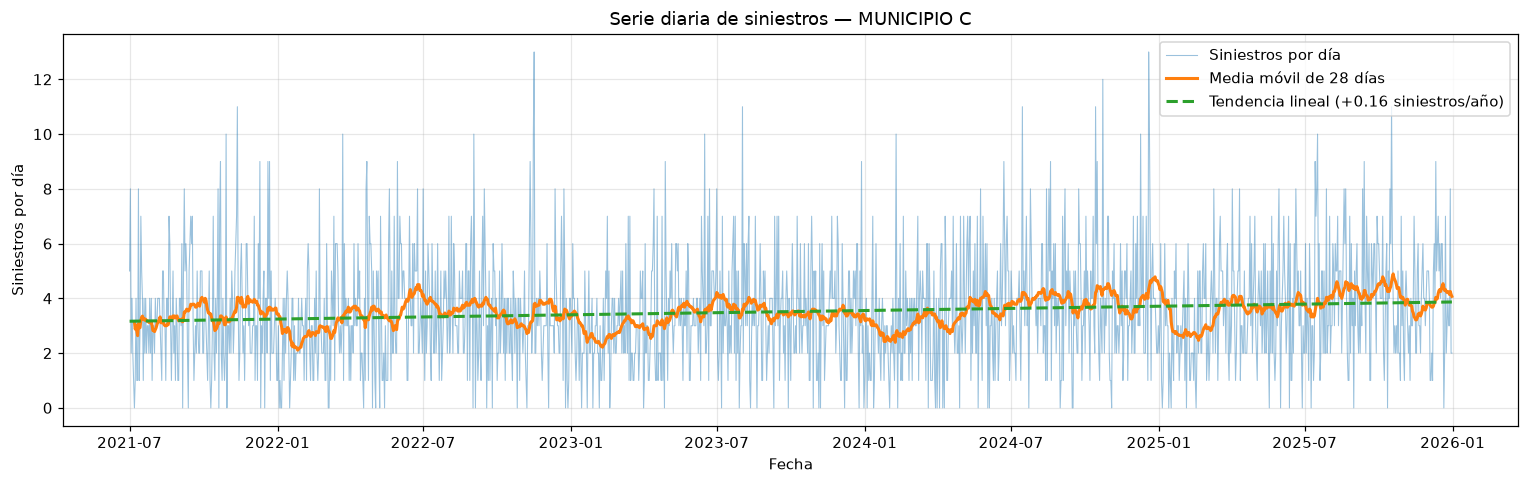

Media 1ª mitad: 3.363
Media 2ª mitad: 3.668
Variación entre mitades: +9.1 %


In [7]:
y = serie_df["n_siniestros"].astype(float)
t_idx = np.arange(len(y))
pend, orig = np.polyfit(t_idx, y.values, 1)
tendencia = np.polyval((pend, orig), t_idx)
mm28 = y.rolling(28, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(y.index, y.values, lw=0.7, alpha=0.45, label="Siniestros por día")
ax.plot(y.index, mm28.values, lw=2, label="Media móvil de 28 días")
ax.plot(y.index, tendencia, lw=2, ls="--",
        label=f"Tendencia lineal ({pend * 365:+.2f} siniestros/año)")
ax.set_title(f"Serie diaria de siniestros — {serie_df['zona_id'].iloc[0]}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig1_serie.png")
plt.show()

print(f"Media 1ª mitad: {y.iloc[:len(y)//2].mean():.3f}")
print(f"Media 2ª mitad: {y.iloc[len(y)//2:].mean():.3f}")
print(f"Variación entre mitades: {100 * (y.iloc[len(y)//2:].mean() / y.iloc[:len(y)//2].mean() - 1):+.1f} %")

## 3. Estructura de calendario

El objetivo depende del tipo de día. La columna `tipo_dia` (codificación del ETL:
`entre_semana` / `fin_semana` / `feriado`) resume el calendario en tres niveles.

Este cálculo es **sólo descriptivo**: usa toda la serie. La línea base de la sección 7
volverá a estimar estas medias **únicamente con el tramo de entrenamiento**.

  guardado: experiments\base\tablas\02_perfil_calendario.csv (3 filas)


  guardado: experiments\base\figuras\fig2_perfil_calendario.png


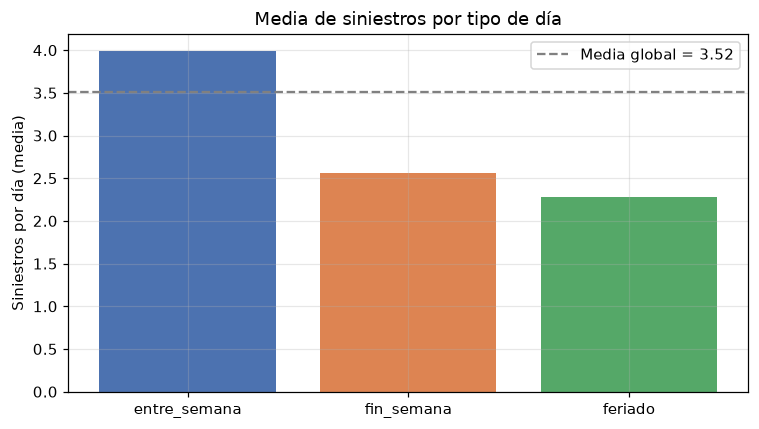

,tipo_dia,dias,media,desvio,factor_vs_global
0,entre_semana,1114,3.988,2.108,1.134
1,fin_semana,454,2.564,1.755,0.729
2,feriado,77,2.286,1.494,0.650


In [8]:
ORDEN_TIPODIA = ["entre_semana", "fin_semana", "feriado"]
perfil_cal = (serie_df.groupby("tipo_dia")["n_siniestros"]
              .agg(dias="count", media="mean", desvio="std")
              .reindex(ORDEN_TIPODIA)
              .reset_index())
perfil_cal["media"] = perfil_cal["media"].round(3)
perfil_cal["desvio"] = perfil_cal["desvio"].round(3)
perfil_cal["factor_vs_global"] = (perfil_cal["media"] / y.mean()).round(3)
guardar_tabla(perfil_cal, "02_perfil_calendario.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(perfil_cal["tipo_dia"], perfil_cal["media"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(y.mean(), color="gray", ls="--", label=f"Media global = {y.mean():.2f}")
ax.set_title("Media de siniestros por tipo de día")
ax.set_ylabel("Siniestros por día (media)")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig2_perfil_calendario.png")
plt.show()
perfil_cal

### Autocorrelación de corto plazo

Comparamos la serie con su valor de un día y de una semana atrás. El diagnóstico encontró
**persistencia genuina a rezago 1** en 5 de los 8 municipios, pero de magnitud pequeña
(una autocorrelación de ~0,05 explica menos del 1 % de la varianza), y que la señal a
rezago 7 es **enteramente de calendario**
(`documentacion/resumen_diagnostico_datos.md`, §5.2).

La celda de abajo lo calcula sobre **toda la serie**, como referencia exploratoria; en la
sección 5 se recalcula **sin el tramo de prueba**. Son autocorrelaciones de Pearson
**crudas**: la tendencia creciente las infla y no descuenta el calendario, así que sirven
de referencia gruesa, no de prueba. La prueba correcta —contra una banda nula de Poisson y
sobre el residuo— es la del diagnóstico.

In [9]:
# Se calcula tras definir las particiones; acá adelantamos el número sobre toda la serie
# como referencia exploratoria (el valor "sin test" se recalcula en la sección 5).
ac_expl = pd.DataFrame({
    "rezago": [1, 7, 14],
    "autocorrelacion": [round(serie_df["n_siniestros"].autocorr(k), 4) for k in (1, 7, 14)],
})
ac_expl

,rezago,autocorrelacion
0,1,0.0785
1,7,0.0768
2,14,0.1724


## 4. Métricas del protocolo

El objetivo es un **conteo** con sobredispersión leve. Las métricas se eligen en
consecuencia:

| Métrica | Para qué | Por qué |
| --- | --- | --- |
| **Desvianza de Poisson media** — *principal* | Comparar y seleccionar modelos | Pondera el error por el nivel del conteo: un error de 1 sobre un valor esperado de 5 pesa menos que sobre uno de 0,5. Es la métrica natural de un objetivo Poisson (`resumen_diagnostico_datos.md`, §5.1). |
| **MAE** | Lectura operativa | "Cuántos siniestros de diferencia, en promedio". Fácil de comunicar, pero trata igual todos los errores de 1 unidad. |
| **RMSE** | Sensibilidad a errores grandes | Penaliza más las desviaciones grandes. |
| **Razón total predicho / observado** | Calibración global | ≈ 1 indica que el modelo no infra- ni sobre-predice el volumen total. |
| **Sesgo medio** (predicho − observado) | Dirección del error | Positivo = sobre-predice; negativo = infra-predice. |

Todas se calculan sobre las **predicciones continuas** del modelo, no redondeadas, igual
que en el ejemplo de series temporales del curso.

In [10]:
EPS = 1e-6  # la desvianza de Poisson exige predicciones estrictamente positivas


def evaluar(y_true, y_pred):
    "Devuelve el diccionario de métricas del protocolo para un tramo."
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), EPS, None)
    return {
        "desvianza_poisson": mean_poisson_deviance(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "razon_total": float(y_pred.sum() / y_true.sum()),
        "sesgo_medio": float(np.mean(y_pred - y_true)),
        "n_dias": int(len(y_true)),
    }


# Comprobación rápida: un predictor perfecto tiene desvianza 0.
_chk = evaluar([1, 2, 3, 4], [1, 2, 3, 4])
print("desvianza de una predicción perfecta:", round(_chk["desvianza_poisson"], 8))

desvianza de una predicción perfecta:

 0.0


## 5. Partición temporal: desarrollo y prueba

En una serie temporal **no se puede partir al azar**: el orden importa y hay que entrenar
con el pasado y evaluar sobre el futuro. Definimos dos bloques cronológicos:

- **Desarrollo** (primer 80 %): todo lo que sigue —exploración de modelos, validación
  interna, elección de la línea base— ocurre acá.
- **Prueba** (último 20 %): **se reserva**. No se usa para calcular medias, ni para elegir
  ventanas, ni para comparar modelos. Se toca una sola vez, en la sección 9.

Dentro de desarrollo, la validación es por **ventana deslizante** (sección 6): se entrena
con un tramo inicial y se evalúa sobre el siguiente, avanzando el origen. El primer 75 %
de desarrollo es el entrenamiento inicial; el 25 % restante son los sucesivos tramos de
validación (60 % y 20 % del total, respectivamente).

In [11]:
HORIZONTE = 7   # días que se predicen en cada corte (horizonte operativo semanal)
PASO = 7        # separación entre orígenes: cortes de validación no solapados
FRAC_TEST = 0.20
FRAC_ENTREN_INICIAL = 0.75

n_total = len(serie_df)
n_test = int(round(n_total * FRAC_TEST))
corte_test = n_total - n_test

serie_desarrollo = serie_df.iloc[:corte_test].copy()
serie_test = serie_df.iloc[corte_test:].copy()   # RESERVADO — no se usa hasta la sección 9

INICIAL = int(round(len(serie_desarrollo) * FRAC_ENTREN_INICIAL))
n_validacion = len(serie_desarrollo) - INICIAL
n_folds_estimado = int(np.ceil(n_validacion / PASO))

particiones = pd.DataFrame({
    "bloque": ["entrenamiento inicial", "validación (ventana deslizante)", "prueba (reservado)"],
    "desde": [serie_desarrollo.index[0].date(),
              serie_desarrollo.index[INICIAL].date(),
              serie_test.index[0].date()],
    "hasta": [serie_desarrollo.index[INICIAL - 1].date(),
              serie_desarrollo.index[-1].date(),
              serie_test.index[-1].date()],
    "dias": [INICIAL, n_validacion, len(serie_test)],
    "pct": [round(100 * INICIAL / n_total, 1),
            round(100 * n_validacion / n_total, 1),
            round(100 * len(serie_test) / n_total, 1)],
})
guardar_tabla(particiones, "03_particiones.csv")
print("Horizonte:", HORIZONTE, "días | Paso:", PASO, "días | Folds de validación estimados:", n_folds_estimado)
particiones

  guardado: experiments\base\tablas\03_particiones.csv (3 filas)
Horizonte: 7 días | Paso: 7 días | Folds de validación estimados: 47


,bloque,desde,hasta,dias,pct
0,entrenamiento inicial,2021-07-01,2024-03-13,987,60.0
1,validación (ventana deslizante),2024-03-14,2025-02-05,329,20.0
2,prueba (reservado),2025-02-06,2025-12-31,329,20.0


### Recordatorio operativo

A partir de acá el objeto `serie_test` **no aparece** hasta la sección 9. Cualquier
media, factor o parámetro se estima sobre `serie_desarrollo` (o sobre la ventana de
entrenamiento de cada corte). Si el test se usara antes, aunque fuera para "mirar", las
métricas finales dejarían de ser una estimación honesta del desempeño futuro.

  guardado: experiments\base\tablas\02b_autocorrelacion.csv (3 filas)


  guardado: experiments\base\figuras\fig3_particion.png


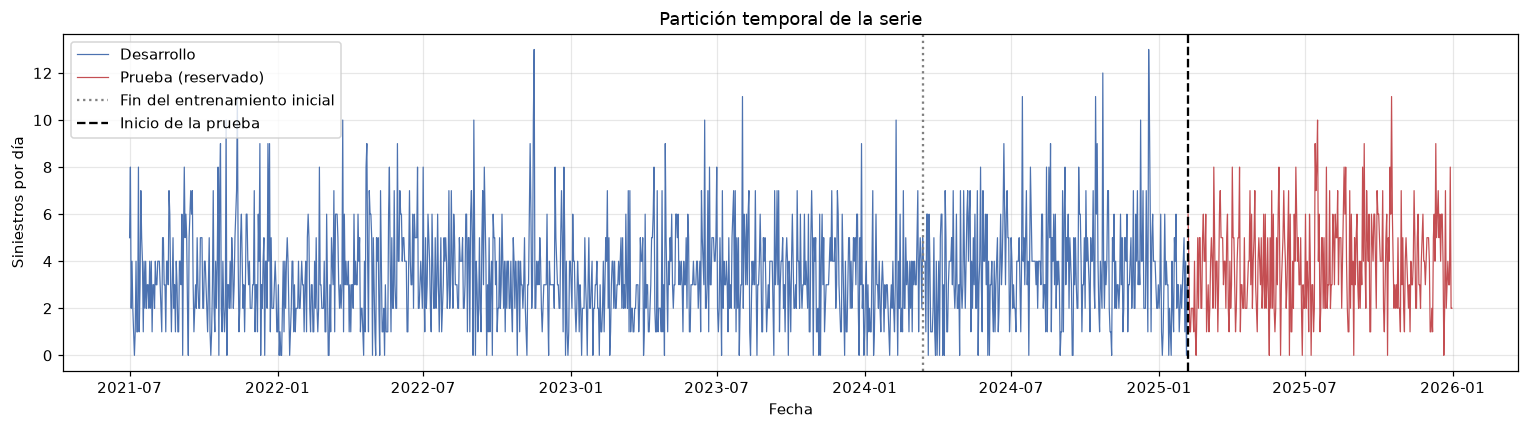

,rezago,autocorrelacion_desarrollo
0,1,0.0557
1,7,0.0770
2,14,0.1653


In [12]:
# Autocorrelación recalculada SIN el test (compárese con la tabla exploratoria de la §3).
ac_dev = pd.DataFrame({
    "rezago": [1, 7, 14],
    "autocorrelacion_desarrollo": [round(serie_desarrollo["n_siniestros"].autocorr(k), 4)
                                   for k in (1, 7, 14)],
})
guardar_tabla(ac_dev, "02b_autocorrelacion.csv")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_desarrollo.index, serie_desarrollo["n_siniestros"], lw=0.8,
        color="#4C72B0", label="Desarrollo")
ax.plot(serie_test.index, serie_test["n_siniestros"], lw=0.8,
        color="#C44E52", label="Prueba (reservado)")
ax.axvline(serie_desarrollo.index[INICIAL], color="gray", ls=":",
           label="Fin del entrenamiento inicial")
ax.axvline(serie_test.index[0], color="black", ls="--",
           label="Inicio de la prueba")
ax.set_title("Partición temporal de la serie")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend(loc="upper left")
fig.tight_layout()
guardar_figura(fig, "fig3_particion.png")
plt.show()
ac_dev

## 6. Backtesting de ventana deslizante

La función `backtesting` recorre la serie de la siguiente forma: parte de un origen
`INICIAL`, entrena un modelo con **todo lo anterior al origen**, predice los siguientes
`HORIZONTE` días, guarda esas predicciones y avanza el origen `PASO` días. La ventana de
entrenamiento **crece** en cada corte (esquema expansivo), como en el ejemplo del curso
con `refit=True`.

Puntos de diseño que evitan la fuga de información:

- Cada modelo recibe dos DataFrames: `historia` (todo lo observado antes del origen, para
  rezagos y niveles recientes) y `ajuste` (el tramo con el que se estiman medias y
  entrena el árbol). En la validación interna `ajuste = historia`; en la evaluación final del
  test `ajuste` queda **fijo** en todo el desarrollo (equivale a `refit=False`).
- La ventana de predicción nunca entra al ajuste.
- Las predicciones se devuelven alineadas por fecha, para poder graficarlas y para
  calcular las métricas sobre el conjunto de todos los tramos de validación.

In [13]:
def backtesting(datos, modelo, inicio, horizonte, paso, ajuste_fijo=None):
    "Backtesting de origen móvil. `modelo(historia, futuro, ajuste) -> array de predicciones`."
    pred = pd.Series(index=datos.index, dtype=float)
    folds = []
    origen = inicio
    while origen < len(datos):
        fin = min(origen + horizonte, len(datos))
        historia = datos.iloc[:origen]
        futuro = datos.iloc[origen:fin]
        ajuste = historia if ajuste_fijo is None else ajuste_fijo
        p = np.asarray(modelo(historia, futuro, ajuste), dtype=float)
        pred.iloc[origen:fin] = p
        folds.append({
            "origen": datos.index[origen].date(),
            "fin": datos.index[fin - 1].date(),
            **evaluar(futuro["n_siniestros"].values, p),
        })
        origen += paso
    return pred, pd.DataFrame(folds)


def resumen_backtest(nombre, datos, pred):
    "Métricas sobre la unión de todos los tramos de validación (predicciones no nulas)."
    mask = pred.notna()
    m = evaluar(datos.loc[mask, "n_siniestros"].values, pred[mask].values)
    return {"modelo": nombre, **m}

## 7. Líneas base

Definimos cuatro modelos simples. Todos se evalúan con **la misma llamada a
`backtesting`**, los mismos cortes y las mismas métricas: sin eso los resultados no serían
comparables.

1. **Media constante.** Predice siempre la media del entrenamiento. Es el piso: cualquier
   modelo útil tiene que superarlo.
2. **Naive estacional (t−7).** Predice el valor de siete días atrás. Es la referencia
   habitual en *forecasting* y recoge el patrón semanal.
3. **Tasa × calendario.** Predice la media del entrenamiento **para ese tipo de día**
   (`entre_semana` / `fin_semana` / `feriado`). Equivale a un nivel global multiplicado
   por un factor de calendario. Es la **forma que el diagnóstico recomienda como línea
   base** (`resumen_diagnostico_datos.md`, §5.3); acá, con una sola zona, se reduce a las
   medias por tipo de día.
4. **Media móvil reciente (56 d) × calendario.** Igual que la anterior, pero el nivel se
   toma de los últimos 56 días observados en vez de todo el historial. Sirve para ver si
   **seguir la tendencia** con una ventana corta ayuda.

In [14]:
def base_media_constante(historia, futuro, ajuste):
    return np.full(len(futuro), ajuste["n_siniestros"].mean())


def base_naive_estacional(historia, futuro, ajuste):
    h = historia["n_siniestros"].to_numpy(dtype=float)
    n = len(h)
    return np.array([h[n - 7 + i] if n - 7 + i >= 0 else h.mean() for i in range(len(futuro))])


def base_tasa_calendario(historia, futuro, ajuste):
    glob = ajuste["n_siniestros"].mean()
    medias = ajuste.groupby("tipo_dia")["n_siniestros"].mean()
    return futuro["tipo_dia"].map(medias).fillna(glob).to_numpy(dtype=float)


def base_movil_calendario(historia, futuro, ajuste, ventana=56):
    glob = ajuste["n_siniestros"].mean()
    factor = ajuste.groupby("tipo_dia")["n_siniestros"].mean() / glob
    nivel = historia["n_siniestros"].iloc[-ventana:].mean()
    return (nivel * futuro["tipo_dia"].map(factor).fillna(1.0)).to_numpy(dtype=float)

### El modelo base: un árbol de decisión básico

Para que la línea base tenga contra qué compararse, construimos **un** modelo aprendido.
El ejemplo de series temporales del curso usa árboles (un `RandomForestRegressor`); acá
usamos su forma más simple: **un único árbol de decisión** (`DecisionTreeRegressor` de
`scikit-learn`), con las mismas variables:

- **rezagos observados**: `y(t−7)`, `y(t−14)`, `y(t−21)` — todos conocidos para un
  horizonte de 7 días, sin recursión;
- **calendario**: indicadoras de `fin_semana` y `feriado` (`entre_semana` es la
  referencia);
- **tendencia**: el tiempo en años desde el inicio.

No se usa `y(t−1)`: exigiría predecir de forma recursiva y el diagnóstico mostró que su
aporte es pequeño. Queda como variable candidata para el notebook del panel.

**"Básico" con un límite de profundidad, y por qué.** Un árbol sin podar sigue partiendo
hasta que cada hoja tiene casi un solo día: memoriza el ruido del entrenamiento y predice
valores muy inestables. La celda siguiente lo muestra con una corrida de comparación. El
modelo base usa un árbol **poco profundo** (`max_depth=4`, `min_samples_leaf=20`): la
configuración mínima para que un árbol sea una referencia sensata.

**Limitación conocida de los árboles, que este notebook va a mostrar en el test.** Un
árbol **no extrapola**: fuera del rango temporal de entrenamiento devuelve el valor de la
última hoja, una **constante**. El diagnóstico ya lo había anticipado para la variable
`anio` («un árbol extrapola a una constante», `resumen_diagnostico_datos.md`, §5.3). Con
la tendencia creciente de la serie, esto le pasa factura.

In [15]:
_COLS_ARBOL = ["y_lag7", "y_lag14", "y_lag21", "t_anios", "es_fin_semana", "es_feriado"]

# Configuración del árbol base: poco profundo, hojas no minúsculas.
ARBOL_KW = dict(max_depth=4, min_samples_leaf=20, random_state=SEMILLA)


def _fila_features(valores, tipos, p, t0):
    return [valores[p - 7], valores[p - 14], valores[p - 21],
            (p - t0) / 365.25,
            1.0 if tipos[p] == "fin_semana" else 0.0,
            1.0 if tipos[p] == "feriado" else 0.0]


def _matriz_entrenamiento(ajuste):
    va = ajuste["n_siniestros"].to_numpy(dtype=float)
    ta = ajuste["tipo_dia"].to_numpy()
    X = [_fila_features(va, ta, p, 0) for p in range(21, len(va))]
    return np.asarray(X), va[21:]


def _matriz_prediccion(historia, futuro):
    vh = historia["n_siniestros"].to_numpy(dtype=float)
    th = historia["tipo_dia"].to_numpy()
    tf = futuro["tipo_dia"].to_numpy()
    n = len(vh)
    # Los rezagos t-7/14/21 caen todos dentro de `historia` para un horizonte de 7 días.
    tt = np.concatenate([th, tf])
    Xf = []
    for i in range(len(futuro)):
        p = n + i
        Xf.append([vh[p - 7], vh[p - 14], vh[p - 21],
                   p / 365.25,
                   1.0 if tt[p] == "fin_semana" else 0.0,
                   1.0 if tt[p] == "feriado" else 0.0])
    return np.asarray(Xf)


def hacer_modelo_arbol(**kw):
    "Devuelve un `ajustar_predecir` que entrena un DecisionTreeRegressor con la config dada."
    params = {**ARBOL_KW, **kw}

    def ajustar_predecir(historia, futuro, ajuste):
        X, obj = _matriz_entrenamiento(ajuste)
        modelo = DecisionTreeRegressor(**params).fit(X, obj)
        return np.clip(modelo.predict(_matriz_prediccion(historia, futuro)), 0.0, None)

    return ajustar_predecir


modelo_arbol = hacer_modelo_arbol()

### Por qué se limita la profundidad — corrida de comparación

Comparamos, con el mismo backtesting de desarrollo, el árbol poco profundo del modelo base
contra un árbol **sin podar** (`DecisionTreeRegressor()` con opciones por omisión).

In [16]:
_variantes_arbol = [
    ("Arbol sin podar (por omision)", dict(max_depth=None, min_samples_leaf=1)),
    ("Arbol base (max_depth=4)", {}),
]
_Xd, _yd = _matriz_entrenamiento(serie_desarrollo)
_filas_prof = []
for _nom, _kw in _variantes_arbol:
    _p, _ = backtesting(serie_desarrollo, hacer_modelo_arbol(**_kw), INICIAL, HORIZONTE, PASO)
    _arb = DecisionTreeRegressor(**{**ARBOL_KW, **_kw}).fit(_Xd, _yd)  # ajustado sobre todo el desarrollo
    _filas_prof.append({**resumen_backtest(_nom, serie_desarrollo, _p),
                        "profundidad": _arb.get_depth(), "hojas": _arb.get_n_leaves()})
tabla_prof = pd.DataFrame(_filas_prof)
for c in ["desvianza_poisson", "mae", "rmse", "razon_total", "sesgo_medio"]:
    tabla_prof[c] = tabla_prof[c].round(4)
guardar_tabla(tabla_prof, "04c_arbol_profundidad.csv")
tabla_prof

  guardado: experiments\base\tablas\04c_arbol_profundidad.csv (2 filas)


,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,n_dias,profundidad,hojas
0,Arbol sin podar (por omision),12.6468,2.4863,3.1652,1.0476,0.1763,329,31,943
1,Arbol base (max_depth=4),1.4005,1.6815,2.1958,0.9981,-0.0071,329,4,13


### Ejecución del backtesting en desarrollo

Corremos los cinco modelos sobre `serie_desarrollo` con ventana deslizante. El test no
participa.

In [17]:
MODELOS = {
    "Media constante": base_media_constante,
    "Naive estacional (t-7)": base_naive_estacional,
    "Tasa x calendario": base_tasa_calendario,
    "Media movil 56d x calendario": base_movil_calendario,
    "Arbol de decision": modelo_arbol,
}

pred_dev = {}
folds_dev = {}
filas_resumen = []
for nombre, fn in MODELOS.items():
    p, f = backtesting(serie_desarrollo, fn, INICIAL, HORIZONTE, PASO)
    pred_dev[nombre] = p
    folds_dev[nombre] = f
    filas_resumen.append({**resumen_backtest(nombre, serie_desarrollo, p),
                          "n_folds": len(f)})

tabla_dev = pd.DataFrame(filas_resumen).sort_values("desvianza_poisson").reset_index(drop=True)
for c in ["desvianza_poisson", "mae", "rmse", "razon_total", "sesgo_medio"]:
    tabla_dev[c] = tabla_dev[c].round(4)
guardar_tabla(tabla_dev, "04_desarrollo_backtesting.csv")
guardar_tabla(folds_dev["Tasa x calendario"].round(4), "04b_folds_linea_base.csv")
tabla_dev

  guardado: experiments\base\tablas\04_desarrollo_backtesting.csv (5 filas)
  guardado: experiments\base\tablas\04b_folds_linea_base.csv (47 filas)


,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,n_dias,n_folds
0,Media movil 56d x calendario,1.3766,1.6501,2.1663,1.0102,0.0377,329,47
1,Tasa x calendario,1.3782,1.6114,2.1641,0.9146,-0.3163,329,47
2,Arbol de decision,1.4005,1.6815,2.1958,0.9981,-0.0071,329,47
3,Media constante,1.5178,1.7591,2.2735,0.9133,-0.3208,329,47
4,Naive estacional (t-7),7.8956,2.3769,3.0647,1.0066,0.0243,329,47


### Lectura de la validación interna

Sobre los 47 cortes de 7 días (`04_desarrollo_backtesting.csv`, `04c_arbol_profundidad.csv`):

- **La poda es imprescindible.** El árbol sin podar llega a **profundidad 31 y 943 hojas**,
  con una desvianza de Poisson de **12,65** — casi diez veces la del árbol base
  `max_depth=4` (**1,40**, 13 hojas). Sin límite de profundidad, cada día del
  entrenamiento termina casi solo en su hoja y el modelo memoriza el ruido.
- **Orden por desvianza en desarrollo:** `Media movil 56d` (1,377) ≈ `Tasa x calendario`
  (1,378) < `Arbol de decision` (1,401) < `Media constante` (1,518) ≪ `Naive estacional`
  (7,90). El árbol base **supera a la media constante** (−7,7 %) pero **queda por debajo
  de las dos formas con calendario** (su desvianza es un 1,6 % peor que la de la línea
  base, y su MAE 1,68 contra 1,61).
- **`Naive estacional (t-7)` queda descartada:** desvianza 7,90, casi seis veces la de la
  media constante. Un único día pasado es una predicción puntual demasiado ruidosa.
- **El árbol calibra casi perfecto en desarrollo** (`razon_total` 0,998 contra 0,915 de la
  línea base), pero es calibración **en muestra**: la §9 mostrará qué pasa fuera.
- **Importancia de variables del árbol** (`05_importancias_arbol.csv`, `fig4b`):
  `es_fin_semana` **53 %**, `t_anios` **23 %**, `es_feriado` **17 %**; los tres rezagos
  juntos **< 8 %** (`y_lag14` exactamente 0). El árbol se apoya en el calendario y algo en
  la tendencia; los rezagos casi no cuentan, coherente con el diagnóstico §5.2.

  guardado: experiments\base\figuras\fig4_desarrollo_predicciones.png


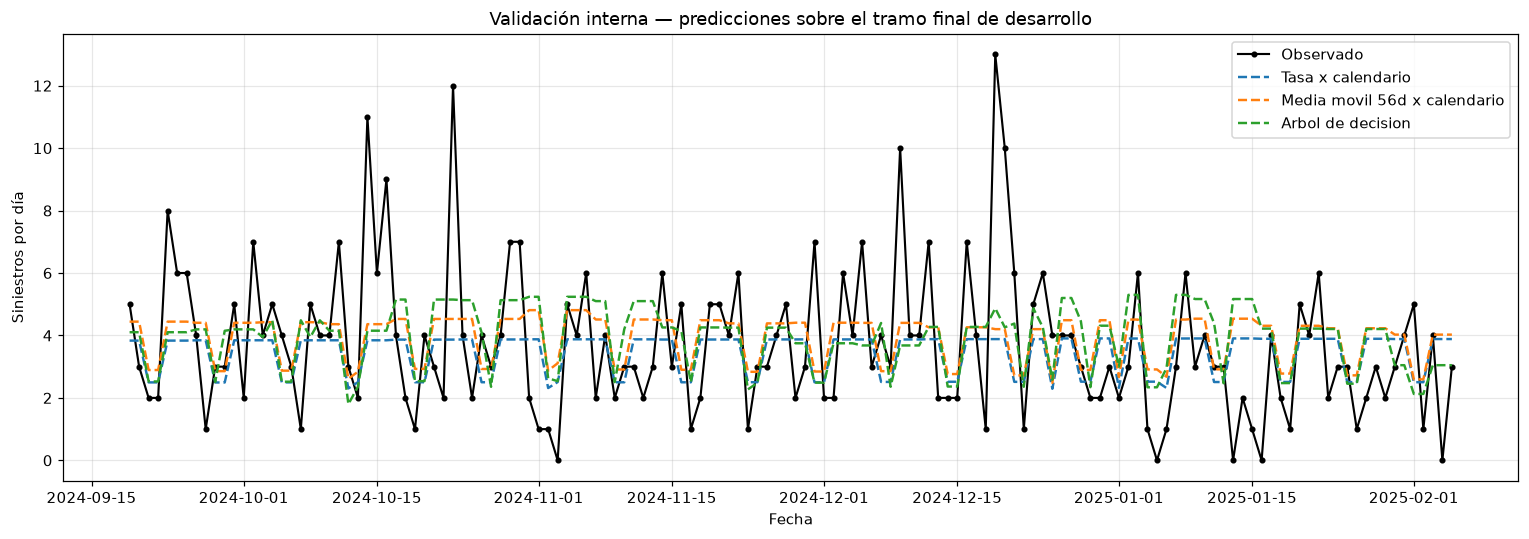

In [18]:
# Predicciones de los últimos ~140 días de desarrollo, para ver el comportamiento.
ventana_fig = serie_desarrollo.index[-140:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ventana_fig, serie_desarrollo.loc[ventana_fig, "n_siniestros"],
        color="black", lw=1.4, marker="o", ms=3, label="Observado")
for nombre in ["Tasa x calendario", "Media movil 56d x calendario", "Arbol de decision"]:
    ax.plot(ventana_fig, pred_dev[nombre].loc[ventana_fig], lw=1.6, ls="--", label=nombre)
ax.set_title("Validación interna — predicciones sobre el tramo final de desarrollo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig4_desarrollo_predicciones.png")
plt.show()

## 8. Selección para la evaluación final

Siguiendo el mismo criterio que el ejemplo del curso, llevamos a la prueba:

- la **línea base del proyecto** — `Tasa x calendario`, la forma que el diagnóstico
  recomienda;
- el **modelo base aprendido** — `Arbol de decision` (`max_depth=4`);
- la **media constante** como piso de comparación.

La configuración de cada uno queda **fija** con lo aprendido en desarrollo. En la prueba
no se estiman medias nuevas ni se reajusta el árbol con datos posteriores al desarrollo:
el ajuste se congela (`ajuste_fijo = serie_desarrollo`) y sólo la historia para los
rezagos avanza a medida que pasan los días, como ocurriría en operación.

  guardado: experiments\base\tablas\05_importancias_arbol.csv (6 filas)
profundidad: 4 | hojas: 13


  guardado: experiments\base\figuras\fig4b_importancias_arbol.png


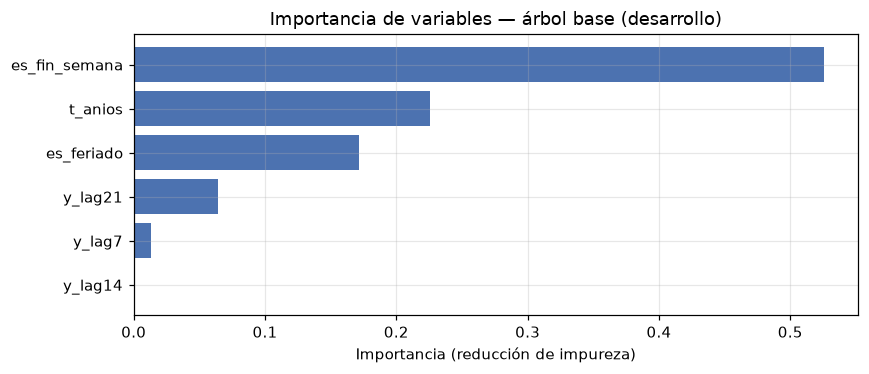

,variable,importancia
0,es_fin_semana,0.5253
1,t_anios,0.2259
2,es_feriado,0.1714
3,y_lag21,0.0644
4,y_lag7,0.0130
5,y_lag14,0.0000


In [19]:
FINALISTAS = ["Media constante", "Tasa x calendario", "Arbol de decision"]

# Árbol base reajustado sobre todo el desarrollo, para inspeccionar su estructura.
_Xd, _yd = _matriz_entrenamiento(serie_desarrollo)
_arbol_dev = DecisionTreeRegressor(**ARBOL_KW).fit(_Xd, _yd)
importancias_arbol = (pd.DataFrame({"variable": _COLS_ARBOL,
                                    "importancia": np.round(_arbol_dev.feature_importances_, 4)})
                      .sort_values("importancia", ascending=False).reset_index(drop=True))
guardar_tabla(importancias_arbol, "05_importancias_arbol.csv")
print("profundidad:", _arbol_dev.get_depth(), "| hojas:", _arbol_dev.get_n_leaves())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(importancias_arbol["variable"], importancias_arbol["importancia"], color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Importancia de variables — árbol base (desarrollo)")
ax.set_xlabel("Importancia (reducción de impureza)")
fig.tight_layout()
guardar_figura(fig, "fig4b_importancias_arbol.png")
plt.show()
importancias_arbol

## 9. Evaluación final sobre el conjunto de prueba

Ahora —y sólo ahora— se usa `serie_test`. Concatenamos desarrollo y prueba para que el
backtesting pueda arrancar justo al inicio del test, y evaluamos los tres finalistas con
el **mismo horizonte, el mismo paso y las mismas métricas** que en desarrollo. El ajuste
queda congelado en el desarrollo.

Este resultado es la estimación del desempeño en datos futuros no vistos. Se reporta una
sola vez y no se vuelve atrás a cambiar nada en función de él.

In [20]:
serie_total = pd.concat([serie_desarrollo, serie_test])
inicio_test = len(serie_desarrollo)

pred_test = {}
filas_test = []
for nombre in FINALISTAS:
    p, f = backtesting(serie_total, MODELOS[nombre], inicio_test, HORIZONTE, PASO,
                       ajuste_fijo=serie_desarrollo)
    pred_test[nombre] = p.iloc[inicio_test:]
    filas_test.append({**resumen_backtest(nombre, serie_total, p), "n_folds": len(f)})

tabla_test = pd.DataFrame(filas_test)
for c in ["desvianza_poisson", "mae", "rmse", "razon_total", "sesgo_medio"]:
    tabla_test[c] = tabla_test[c].round(4)
guardar_tabla(tabla_test, "06_evaluacion_test.csv")
tabla_test

  guardado: experiments\base\tablas\06_evaluacion_test.csv (3 filas)


,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,n_dias,n_folds
0,Media constante,1.2625,1.7411,2.1199,0.8839,-0.4498,329,47
1,Tasa x calendario,1.0848,1.5919,1.9667,0.8841,-0.4493,329,47
2,Arbol de decision,1.6789,1.9055,2.4087,0.7229,-1.0737,329,47


In [21]:
# Comparación desarrollo vs test para los finalistas.
comp = (tabla_dev[tabla_dev["modelo"].isin(FINALISTAS)][["modelo", "desvianza_poisson", "mae", "razon_total"]]
        .rename(columns={"desvianza_poisson": "desv_poisson_dev", "mae": "mae_dev", "razon_total": "razon_dev"}))
comp = comp.merge(
    tabla_test[["modelo", "desvianza_poisson", "mae", "razon_total"]].rename(
        columns={"desvianza_poisson": "desv_poisson_test", "mae": "mae_test", "razon_total": "razon_test"}),
    on="modelo")
guardar_tabla(comp.round(4), "06b_desarrollo_vs_test.csv")
comp

  guardado: experiments\base\tablas\06b_desarrollo_vs_test.csv (3 filas)


,modelo,desv_poisson_dev,mae_dev,razon_dev,desv_poisson_test,mae_test,razon_test
0,Tasa x calendario,1.3782,1.6114,0.9146,1.0848,1.5919,0.8841
1,Arbol de decision,1.4005,1.6815,0.9981,1.6789,1.9055,0.7229
2,Media constante,1.5178,1.7591,0.9133,1.2625,1.7411,0.8839


  guardado: experiments\base\figuras\fig5_test_predicciones.png


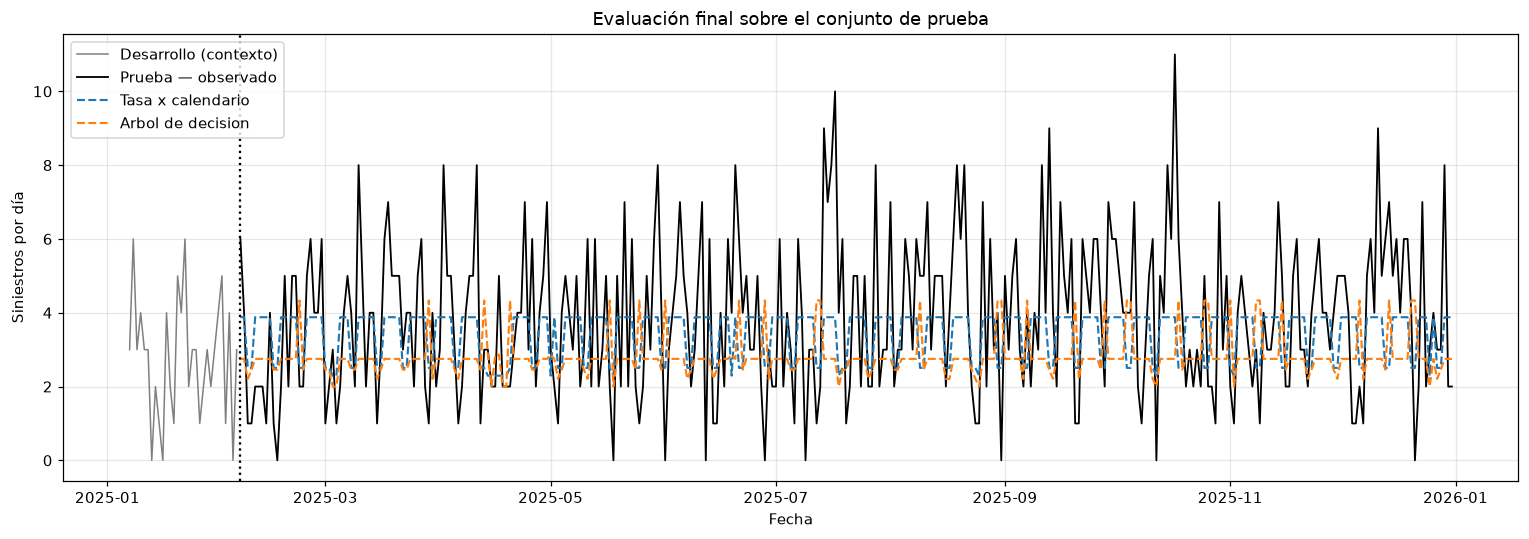

In [22]:
# Figura: observado vs finalistas en el test, con 30 días de contexto.
ctx = serie_desarrollo.index[-30:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ctx, serie_desarrollo.loc[ctx, "n_siniestros"], color="gray", lw=1, label="Desarrollo (contexto)")
ax.plot(serie_test.index, serie_test["n_siniestros"], color="black", lw=1.2, label="Prueba — observado")
for nombre in ["Tasa x calendario", "Arbol de decision"]:
    ax.plot(serie_test.index, pred_test[nombre], lw=1.4, ls="--", label=nombre)
ax.axvline(serie_test.index[0], color="black", ls=":")
ax.set_title("Evaluación final sobre el conjunto de prueba")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig5_test_predicciones.png")
plt.show()

  guardado: experiments\base\tablas\07_calibracion_mensual_test.csv (11 filas)


  guardado: experiments\base\figuras\fig6_calibracion_test.png


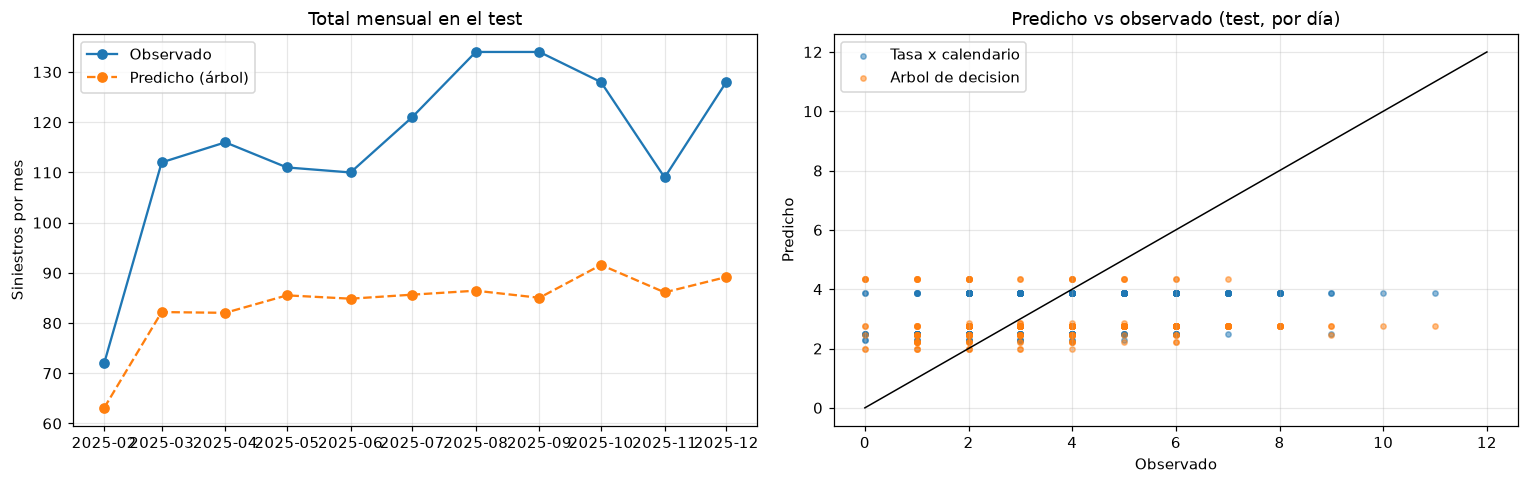

,fecha,observado,predicho,razon
0,2025-02,72,63.116909,0.877
1,2025-03,112,82.194175,0.734
2,2025-04,116,82.041152,0.707
3,2025-05,111,85.522212,0.770
4,2025-06,110,84.857568,0.771
5,2025-07,121,85.656553,0.708
6,2025-08,134,86.450243,0.645
7,2025-09,134,85.037621,0.635
8,2025-10,128,91.581311,0.715
9,2025-11,109,86.118932,0.790


In [23]:
# Calibración en el test: total mensual observado vs predicho (modelo base aprendido).
mens = pd.DataFrame({"observado": serie_test["n_siniestros"]})
mens["predicho"] = pred_test["Arbol de decision"]
mens_m = mens.resample("MS").sum()
calib_mens = mens_m.assign(razon=(mens_m["predicho"] / mens_m["observado"]).round(3)).reset_index()
calib_mens["fecha"] = calib_mens["fecha"].dt.strftime("%Y-%m")
guardar_tabla(calib_mens, "07_calibracion_mensual_test.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(mens_m.index, mens_m["observado"], marker="o", label="Observado")
axes[0].plot(mens_m.index, mens_m["predicho"], marker="o", ls="--", label="Predicho (árbol)")
axes[0].set_title("Total mensual en el test")
axes[0].set_ylabel("Siniestros por mes")
axes[0].legend()

for nombre in ["Tasa x calendario", "Arbol de decision"]:
    axes[1].scatter(serie_test["n_siniestros"], pred_test[nombre], s=12, alpha=0.5, label=nombre)
lim = [0, serie_test["n_siniestros"].max() + 1]
axes[1].plot(lim, lim, color="black", lw=1)
axes[1].set_xlabel("Observado")
axes[1].set_ylabel("Predicho")
axes[1].set_title("Predicho vs observado (test, por día)")
axes[1].legend()
fig.tight_layout()
guardar_figura(fig, "fig6_calibracion_test.png")
plt.show()
calib_mens

## 10. Interpretación de los resultados preliminares

Los artefactos que respaldan cada cifra están entre paréntesis.

### Qué quedó fijado

- **Protocolo.** Partición cronológica 80 / 20 con el 20 % final **reservado**
  (`03_particiones.csv`: desarrollo 2021-07-01 → 2025-02-05, prueba 2025-02-06 →
  2025-12-31). Validación interna por ventana deslizante sobre el desarrollo — 47 cortes
  de 7 días, no solapados. Métrica principal: **desvianza de Poisson**; acompañan MAE,
  RMSE y dos medidas de calibración (`04_desarrollo_backtesting.csv`).
- **Sin fugas.** Toda media, factor o parámetro se estima con la ventana de
  entrenamiento de cada corte; en el test el ajuste queda congelado en el desarrollo. El
  test se usó una sola vez (`06_evaluacion_test.csv`).
- **Línea base del proyecto:** `Tasa × calendario` — nivel del entrenamiento por tipo de
  día. Es la forma multiplicativa que el diagnóstico recomienda.

### Qué muestran los resultados

- **La poda del árbol es imprescindible** (`04c_arbol_profundidad.csv`): sin podar llega a
  profundidad 31 / 943 hojas y desvianza **12,65**; el árbol `max_depth=4` (13 hojas) baja
  a **1,40**. Un árbol básico **necesita un límite de profundidad** para ser admisible.
- **En desarrollo** (`04_desarrollo_backtesting.csv`), el árbol base (desvianza **1,401**)
  queda **entre** la media constante (1,518 — la supera en −7,7 %) y la línea base
  `Tasa × calendario` (1,378 — que a su vez es 1,6 % mejor que el árbol). Su calibración
  **en muestra** es casi perfecta (`razon_total` 0,998).
- La **ventana reciente de 56 días** tiene la misma desvianza que la línea base pero mejor
  calibración (0,915 → 1,010): acercar el nivel a los últimos días corrige el sesgo, señal
  de que la tendencia **conviene tratarla explícitamente**.
- **En el test el árbol es el peor de los tres finalistas**
  (`06_evaluacion_test.csv`, `06b_desarrollo_vs_test.csv`): desvianza **1,679**, contra
  **1,085** de la línea base y **1,263** de la media constante. Su razón total
  predicho/observado cae a **0,723** (infra-predice un 28 %; sesgo −1,07 siniestros/día),
  y el detalle mensual baja hasta **0,64** en agosto–septiembre de 2025
  (`07_calibracion_mensual_test.csv`).
- **Causa: el árbol no extrapola.** El diagnóstico lo anticipó para `anio`
  (`resumen_diagnostico_datos.md`, §5.3). En el test la variable `t_anios` cae siempre
  fuera del rango de entrenamiento, así que todas las filas terminan en la misma hoja
  —entrenada con el tramo final del desarrollo, que por la tendencia creciente ya está por
  debajo del nivel del test—. La línea base también infra-predice (0,884) pero mucho menos.
- **Importancia de variables del árbol** (`05_importancias_arbol.csv`): `es_fin_semana`
  53 %, `t_anios` 23 %, `es_feriado` 17 %; los rezagos juntos < 8 %. Coherente con que la
  persistencia de corto plazo es despreciable (diagnóstico §5.2).
- **El protocolo funcionó.** Un modelo que en desarrollo parecía competitivo y bien
  calibrado se cae en el test. Para eso sirve el conjunto reservado.

### Conclusión preliminar

La **línea base del proyecto sigue siendo `Tasa × calendario`**: es la mejor de las
opciones evaluadas fuera de muestra (desvianza 1,085 en el test). Un **árbol de decisión
básico** sirve para poner el modelo aprendido en marcha, pero **no es un modelo final
adecuado para esta serie**: no puede seguir la tendencia creciente y en el test rinde peor
que predecir la media. El notebook del panel tiene que **tratar la tendencia
explícitamente** y probar familias que extrapolen o recalibren el nivel.

### Limitaciones y lo que NO puede afirmarse

- **Es una sola serie.** MUNICIPIO C no representa al proyecto. Estas cifras **no** son
  las del sistema y **no** se puede concluir que un modelo "generaliza": eso se mide en
  el panel de los 8 municipios con métricas desagregadas.
- **El clima es observado, no pronosticado.** No entra en este notebook; cuando entre, el
  desempeño medido será una **cota optimista** del operativo.
- **La tendencia no se trató explícitamente.** El árbol recibe el tiempo como variable
  pero **no la extrapola**, y la línea base tampoco la modela. La recalibración de nivel
  o la ponderación de datos recientes quedan para el modelado del panel.
- **El árbol es un modelo de arranque, no ajustado.** `max_depth=4` se fijó a mano, no por
  búsqueda; la selección de modelo e hiperparámetros es el Entregable 3.
- **El horizonte es fijo en 7 días.** Otros horizontes pueden dar otras conclusiones.
- **El rezago de 1 día no se usó.** Su aporte es pequeño según el diagnóstico; se evaluará
  como candidato en el panel.

**Frases que no deben aparecer en el informe a partir de este notebook:**

- ❌ «El modelo predice cuándo o dónde ocurrirá un siniestro.» → estima el **conteo
  esperado** por día.
- ❌ «MUNICIPIO C es el más peligroso.» → es el que más siniestros **registra**.
- ❌ «El modelo generaliza / funciona bien en Montevideo.» → se evaluó **una sola serie**.
- ❌ «Se eliminó la tendencia / la estacionalidad.» → el árbol ni siquiera la extrapola.
- ❌ «El árbol de decisión es el modelo final del proyecto.» → es el modelo **base de
  arranque**; la selección de modelo es el Entregable 3.
- ❌ «El árbol sin podar da mejores resultados.» → `04c_arbol_profundidad.csv` muestra lo
  contrario: memoriza el ruido del entrenamiento.

### Qué queda para el notebook del panel

1. Repetir el protocolo sobre el panel día × municipio (8 zonas), con métricas
   desagregadas.
2. Construir la **tasa histórica por municipio** ajustada sólo con entrenamiento (el
   bloque más útil fuera de muestra según el diagnóstico).
3. Evaluar el **rezago de 1 día** como variable candidata.
4. Tratar la **tendencia creciente** de forma explícita.
5. Decidir el destino del **clima** (fuera de muestra no aportó nada en el diagnóstico).
6. Diseñar el **hold-out de zonas** dejando un municipio afuera por vez.
7. Comparar el árbol base contra **familias apropiadas para conteo** (regresión de Poisson,
   boosting con pérdida Poisson, `RandomForest` como en el ejemplo del curso) y ajustar
   hiperparámetros con validación temporal — Entregable 3.

## 11. Índice de artefactos

`experiments/base/` — tablas y figuras que respaldan cada afirmación de este notebook y
del documento acompañante `documentacion/resumen_base.md`.

In [24]:
indice = pd.DataFrame([
    ("tablas/01_serie_resumen.csv", "Estadísticos de la serie de MUNICIPIO C (§1)"),
    ("tablas/02_perfil_calendario.csv", "Media por tipo de día y factor vs global (§3)"),
    ("tablas/02b_autocorrelacion.csv", "Autocorrelación a rezagos 1/7/14 sin el test (§5)"),
    ("tablas/03_particiones.csv", "Bloques de entrenamiento, validación y prueba (§5)"),
    ("tablas/04_desarrollo_backtesting.csv", "Métricas de los 5 modelos en validación interna (§7)"),
    ("tablas/04b_folds_linea_base.csv", "Métricas por corte de la línea base (§7)"),
    ("tablas/04c_arbol_profundidad.csv", "Árbol sin podar vs árbol base: desvianza, profundidad, hojas (§7)"),
    ("tablas/05_importancias_arbol.csv", "Importancia de variables del árbol base (§8)"),
    ("tablas/06_evaluacion_test.csv", "Métricas de los finalistas en el test (§9)"),
    ("tablas/06b_desarrollo_vs_test.csv", "Comparación desarrollo vs test (§9)"),
    ("tablas/07_calibracion_mensual_test.csv", "Total mensual observado vs predicho en test (§9)"),
    ("figuras/fig1_serie.png", "Serie diaria, media móvil y tendencia (§2)"),
    ("figuras/fig2_perfil_calendario.png", "Media por tipo de día (§3)"),
    ("figuras/fig3_particion.png", "Partición temporal (§5)"),
    ("figuras/fig4_desarrollo_predicciones.png", "Predicciones en el tramo final de desarrollo (§7)"),
    ("figuras/fig4b_importancias_arbol.png", "Importancia de variables del árbol base (§8)"),
    ("figuras/fig5_test_predicciones.png", "Observado vs finalistas en el test (§9)"),
    ("figuras/fig6_calibracion_test.png", "Calibración en el test (§9)"),
], columns=["artefacto", "qué respalda"])
guardar_tabla(indice, "08_artefactos.csv")
indice

  guardado: experiments\base\tablas\08_artefactos.csv (18 filas)


,artefacto,qué respalda
0,tablas/01_serie_resumen.csv,Estadísticos de la serie de MUNICIPIO C (§1)
1,tablas/02_perfil_calendario.csv,Media por tipo de día y factor vs global (§3)
2,tablas/02b_autocorrelacion.csv,Autocorrelación a rezagos 1/7/14 sin el test (§5)
3,tablas/03_particiones.csv,"Bloques de entrenamiento, validación y prueba ..."
4,tablas/04_desarrollo_backtesting.csv,Métricas de los 5 modelos en validación intern...
5,tablas/04b_folds_linea_base.csv,Métricas por corte de la línea base (§7)
6,tablas/04c_arbol_profundidad.csv,"Árbol sin podar vs árbol base: desvianza, prof..."
7,tablas/05_importancias_arbol.csv,Importancia de variables del árbol base (§8)
8,tablas/06_evaluacion_test.csv,Métricas de los finalistas en el test (§9)
9,tablas/06b_desarrollo_vs_test.csv,Comparación desarrollo vs test (§9)
